In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import gala.dynamics as gd
import gala.potential as gp
import astropy.units as u
import astropy.coordinates as coord

# Runaways

# NGC 6231 astrometry & 4U 1700-37 astrometry

In [2]:
ra_ngc6231 = 253.542202  # deg
dec_ngc6231 = -41.8245107 # deg
pmra_ngc6231 = -0.529 # mas/yr
pmra_error_ngc6231 = 0.007 # mas/yr
pmdec_ngc6231 = -2.177 # mas/yr
pmdec_error_ngc6231 = 0.007 # mas/yr
parallax_ngc6231 = 0.589 # mas
parallax_error_ngc6231 = 0.002 # mas
radial_velocity_ngc6231 = -25.0 # km/s


In [3]:
ra_1700min37 = 255.986552  # deg
dec_1700min37 = -37.8441425 # deg
pmra_1700min37 = 2.414 # mas/yr
pmra_error_1700min37 = 0.028 # mas/yr
pmdec_1700min37 = 5.022 # mas/yr
pmdec_error_1700min37 = 0.021 # mas/yr
parallax_1700min37 = 0.6327 # mas
parallax_error_1700min37 = 0.0259 # mas
radial_velocity_1700min37 = -64.5 # km/s


# Calculate back in time

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


22.8859247923905 pc
-2.409 Myr ago


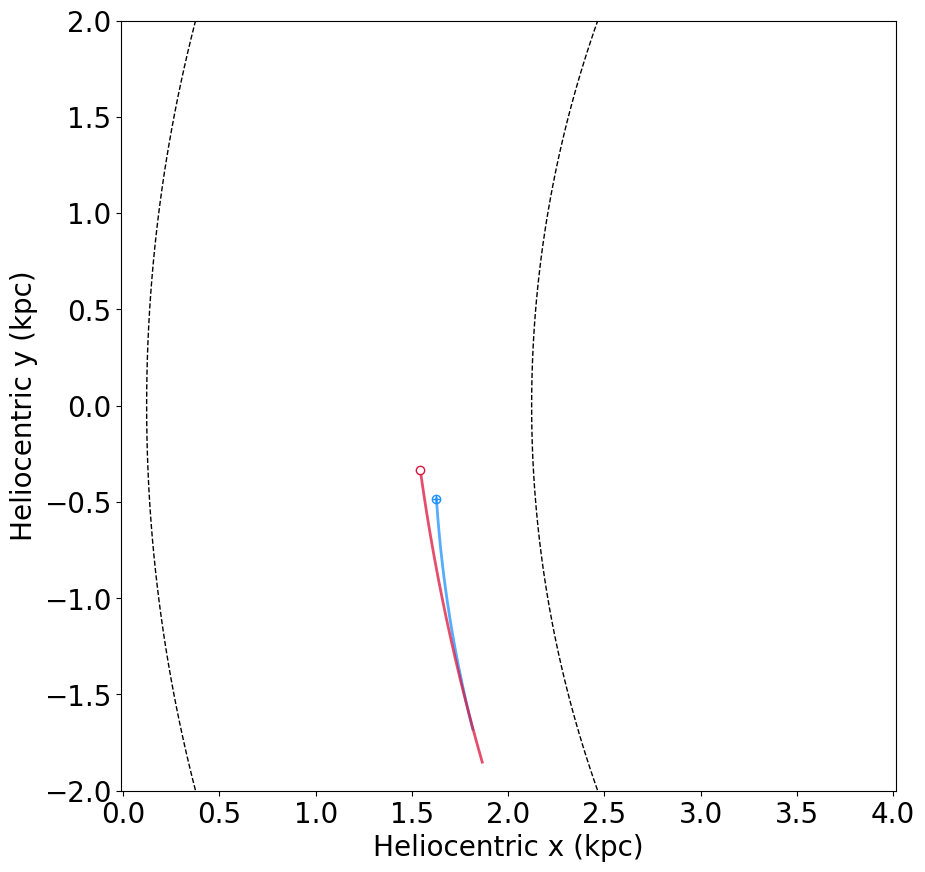

In [4]:
fig, ax = plt.subplots(1, figsize=(10,10))

t = -5.0e6
t_step = 1e3
t_array = np.flip(np.arange(t-t_step, 0.0+t_step, t_step))
with coord.galactocentric_frame_defaults.set('v4.0'):
    galcen_frame = coord.Galactocentric()
mw_potential = gp.MilkyWayPotential()

# 4U 1700-37
coords_1700min37 = coord.SkyCoord(ra=ra_1700min37*u.deg, dec=dec_1700min37*u.deg, distance=(1/parallax_1700min37)*u.kpc, pm_ra_cosdec=pmra_1700min37*u.mas/u.yr, pm_dec=pmdec_1700min37*u.mas/u.yr, radial_velocity=radial_velocity_1700min37*u.km/u.s)
galcen_1700min37 = coords_1700min37.transform_to(galcen_frame)
w0_1700min37 = gd.PhaseSpacePosition(galcen_1700min37.data)
orbit_1700min37 = mw_potential.integrate_orbit(w0_1700min37, dt=-1*(t_step/1e3)*u.kyr, t1=0, t2=((t-t_step)/1e6)*u.Myr)

# NGC 6231
coords_ngc6231 = coord.SkyCoord(ra=ra_ngc6231*u.deg, dec=dec_ngc6231*u.deg, distance=(1/parallax_ngc6231)*u.kpc, pm_ra_cosdec=pmra_ngc6231*u.mas/u.yr, pm_dec=pmdec_ngc6231*u.mas/u.yr, radial_velocity=radial_velocity_ngc6231*u.km/u.s)
galcen_ngc6231 = coords_ngc6231.transform_to(galcen_frame)
w0_ngc6231 = gd.PhaseSpacePosition(galcen_ngc6231.data)
orbit_ngc6231 = mw_potential.integrate_orbit(w0_ngc6231, dt=-1*(t_step/1e3)*u.kyr, t1=0, t2=((t-t_step)/1e6)*u.Myr)

ax.plot(np.array(orbit_ngc6231.x)+8.122, np.array(orbit_ngc6231.y),
        color='dodgerblue', ls='-', marker='', lw=2, zorder=-1, alpha=0.75)
ax.plot(np.array(orbit_ngc6231.x)[0]+8.122, np.array(orbit_ngc6231.y)[0],
        color='dodgerblue', ls='-', marker='o', mfc='None', mec='dodgerblue', lw=1, zorder=1)
ax.plot(np.array(orbit_ngc6231.x)[0]+8.122, np.array(orbit_ngc6231.y)[0],
        color='dodgerblue', ls='-', marker='+', mfc='None', mec='dodgerblue', lw=1, zorder=1)

ax.plot(np.array(orbit_1700min37.x)+8.122, np.array(orbit_1700min37.y),
        color='crimson', ls='-', marker='', lw=2, zorder=1, alpha=0.75)
ax.plot(np.array(orbit_1700min37.x)[0]+8.122, np.array(orbit_1700min37.y)[0],
        'ro', ls='', mfc='w', mec='crimson')

ax.plot(8.122, 0., 'ko')
ax.plot(2*np.cos(np.arange(0, 2*np.pi, 0.01)) + 8.122, 2*np.sin(np.arange(0, 2*np.pi, 0.01)), 'k--', lw=1)
ax.plot(4*np.cos(np.arange(0, 2*np.pi, 0.01)) + 8.122, 4*np.sin(np.arange(0, 2*np.pi, 0.01)), 'k--', lw=1)
ax.plot(6*np.cos(np.arange(0, 2*np.pi, 0.01)) + 8.122, 6*np.sin(np.arange(0, 2*np.pi, 0.01)), 'k--', lw=1)
ax.plot(8*np.cos(np.arange(0, 2*np.pi, 0.01)) + 8.122, 8*np.sin(np.arange(0, 2*np.pi, 0.01)), 'k--', lw=1)

difference = np.sqrt((np.array(orbit_1700min37.x) - np.array(orbit_ngc6231.x))**2 + (np.array(orbit_1700min37.y) - np.array(orbit_ngc6231.y))**2 + (np.array(orbit_1700min37.z) - np.array(orbit_ngc6231.z))**2)
print(np.amin(difference)*1e3, 'pc')
print(t_array[np.argmin(difference)]/1e6, 'Myr ago')

ax.axis('equal')
ax.set_xlabel(r'Heliocentric x (kpc)', fontsize=20)
ax.set_ylabel(r'Heliocentric y (kpc)', fontsize=20)
ax.tick_params(labelsize=20)
ax.set_xlim(0, 4)
ax.set_ylim(-2,2)
# plt.savefig('helio_x_y_view.png', dpi=100)
plt.show()

In [5]:
t_array

array([ 0.000e+00, -1.000e+03, -2.000e+03, ..., -4.999e+06, -5.000e+06,
       -5.001e+06])

22.8859247923905
0.2409


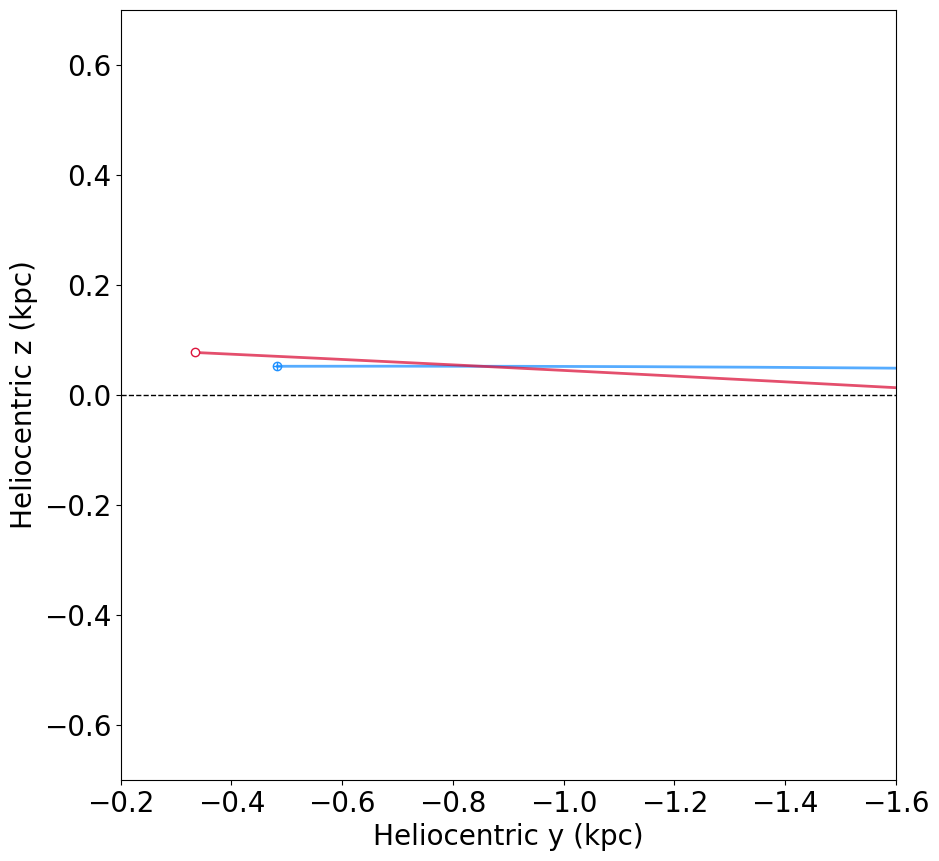

In [6]:
fig, ax = plt.subplots(1, figsize=(10,10))

ax.plot(np.array(orbit_ngc6231.y), np.array(orbit_ngc6231.z),
        color='dodgerblue', ls='-', marker='', lw=2, zorder=-1, alpha=0.75)
ax.plot(np.array(orbit_ngc6231.y)[0], np.array(orbit_ngc6231.z)[0],
        color='dodgerblue', ls='-', marker='o', mfc='None', mec='dodgerblue', lw=1, zorder=1)
ax.plot(np.array(orbit_ngc6231.y)[0], np.array(orbit_ngc6231.z)[0],
        color='dodgerblue', ls='-', marker='+', mfc='None', mec='dodgerblue', lw=1, zorder=1)

ax.plot(np.array(orbit_1700min37.y), np.array(orbit_1700min37.z),
        color='crimson', ls='-', marker='', lw=2, zorder=1, alpha=0.75)
ax.plot(np.array(orbit_1700min37.y)[0], np.array(orbit_1700min37.z)[0],
        'ro', ls='', mfc='w', mec='crimson')


ax.axhline(0., color='k', ls='--', lw=1)

difference = np.sqrt((np.array(orbit_1700min37.x) - np.array(orbit_ngc6231.x))**2 + (np.array(orbit_1700min37.y) - np.array(orbit_ngc6231.y))**2 + (np.array(orbit_1700min37.z) - np.array(orbit_ngc6231.z))**2)
print(np.amin(difference)*1e3)
print(1e2*np.argmin(difference)/1e6)


# ax.axis('equal')
ax.set_xlabel(r'Heliocentric y (kpc)', fontsize=20)
ax.set_ylabel(r'Heliocentric z (kpc)', fontsize=20)
ax.tick_params(labelsize=20)
ax.set_xlim(-1.6, -0.2)
ax.set_ylim(-0.7, 0.7)
plt.gca().invert_xaxis()
# plt.savefig('helio_y_z_view.png', dpi=100)

plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


22.8859247923905
0.2409


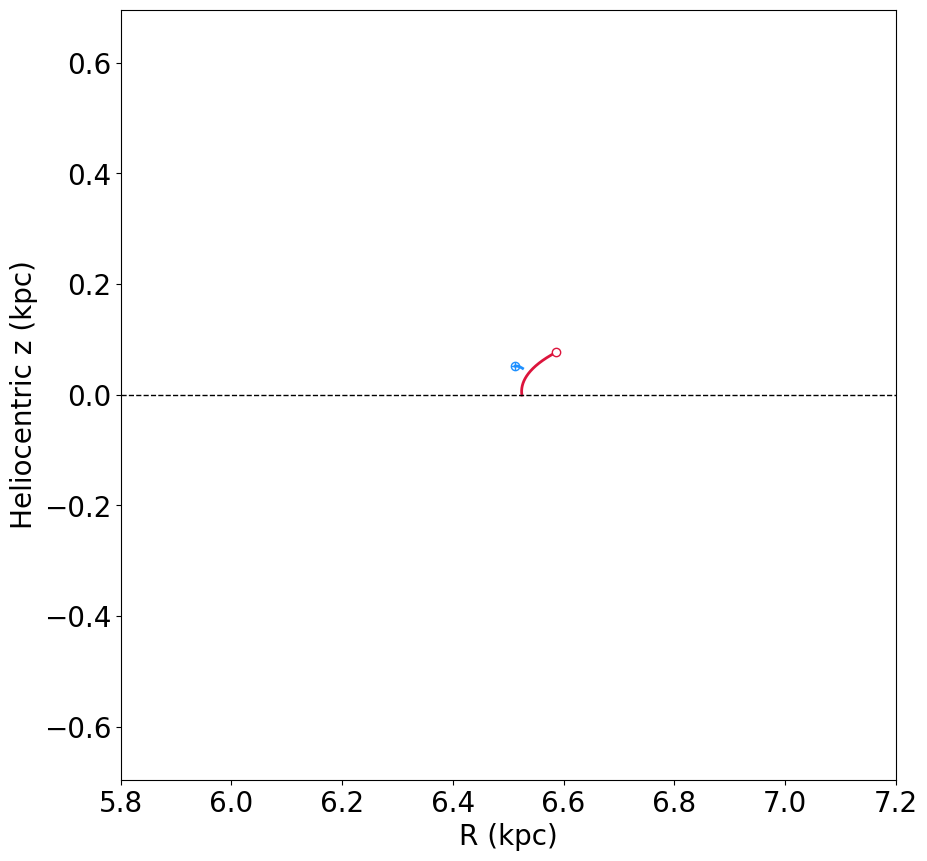

In [7]:
fig, ax = plt.subplots(1, figsize=(10,10))

ax.plot(np.sqrt(np.array(orbit_ngc6231.x)**2 + np.array(orbit_ngc6231.y)**2), np.array(orbit_ngc6231.z), color='dodgerblue', ls='-', marker='', lw=2, zorder=-1)
ax.plot(np.sqrt(np.array(orbit_ngc6231.x)[0]**2 + np.array(orbit_ngc6231.y)[0]**2), np.array(orbit_ngc6231.z)[0], color='dodgerblue', ls='-', marker='o', mfc='None', mec='dodgerblue', lw=1, zorder=1)
ax.plot(np.sqrt(np.array(orbit_ngc6231.x)[0]**2 + np.array(orbit_ngc6231.y)[0]**2), np.array(orbit_ngc6231.z)[0], color='dodgerblue', ls='-', marker='+', mfc='None', mec='dodgerblue', lw=1, zorder=1)

ax.plot(np.sqrt(np.array(orbit_1700min37.x)**2 + np.array(orbit_1700min37.y)**2), np.array(orbit_1700min37.z), color='crimson', ls='-', marker='', lw=2, zorder=1)
ax.plot(np.sqrt(np.array(orbit_1700min37.x)[0]**2 + np.array(orbit_1700min37.y)[0]**2), np.array(orbit_1700min37.z)[0], 'ro', ls='', mfc='w', mec='crimson')


ax.axhline(0., color='k', ls='--', lw=1)

difference = np.sqrt((np.array(orbit_1700min37.x) - np.array(orbit_ngc6231.x))**2 + (np.array(orbit_1700min37.y) - np.array(orbit_ngc6231.y))**2 + (np.array(orbit_1700min37.z) - np.array(orbit_ngc6231.z))**2)
print(np.amin(difference)*1e3)
print(1e2*np.argmin(difference)/1e6)


ax.axis('equal')
ax.set_xlabel(r'R (kpc)', fontsize=20)
ax.set_ylabel(r'Heliocentric z (kpc)', fontsize=20)
ax.tick_params(labelsize=20)
ax.set_xlim(6.5 - 0.7, 6.5 + 0.7)
ax.set_ylim(-0.7, 0.7)
# plt.gca().invert_xaxis()
# plt.savefig('helio_R_z_view.png', dpi=100)
plt.show()

22.8859247923905 pc
-2.409 Myr ago


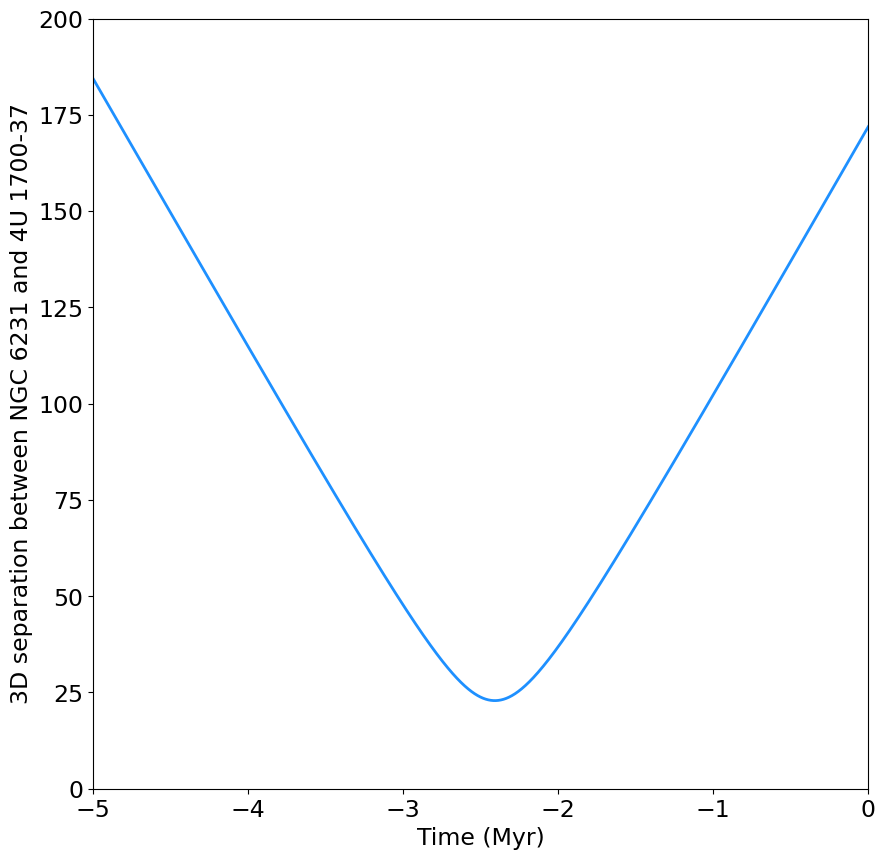

In [8]:
fig, ax = plt.subplots(1, figsize=(10,10))

difference = np.sqrt(((np.array(orbit_1700min37.x) - np.array(orbit_ngc6231.x))**2) + ((np.array(orbit_1700min37.y) - np.array(orbit_ngc6231.y))**2) + ((np.array(orbit_1700min37.z) - np.array(orbit_ngc6231.z))**2))
print(np.amin(difference)*1e3, 'pc')
print(t_array[np.argmin(difference)]/1e6, 'Myr ago')

ax.plot(t_array/1e6, difference*1e3, color='dodgerblue', ls='-', marker='', lw=2, zorder=-1)

# ax.axis('equal')
ax.set_xlabel(r'Time (Myr)', fontsize=17)
ax.set_ylabel(r'3D separation between NGC 6231 and 4U 1700-37', fontsize=17)
ax.tick_params(labelsize=17)
ax.set_xlim(-5.0, 0.0)
ax.set_ylim(0, 200)
# plt.gca().invert_xaxis()
plt.savefig('time_separation.png', dpi=100)
plt.show()